# Clebsch Hodograph Public Demo

This notebook is the public, result-saved front door for the Clebsch/hodograph line. It shows the theory map, the representative runnable examples, and their saved result artifacts without moving the protected validation scripts yet.

The full source/result catalog is [`examples_catalog.ipynb`](examples_catalog.ipynb). The runnable companions in [`docs/clebsch_hodograph/demos/`](demos/) are part of the documented result chain because `validation_test/feec/test_clebsch_hodograph_research.py` golden-locks them directly.


In [1]:
from pathlib import Path
import json
from IPython.display import Markdown, Image, display

CWD = Path.cwd()
if (CWD / 'public_demo_results.json').exists():
    NOTEBOOK_DIR = CWD
    REPO = NOTEBOOK_DIR.parents[1]
else:
    REPO = CWD
    NOTEBOOK_DIR = REPO / 'docs' / 'clebsch_hodograph'

demo = json.loads((NOTEBOOK_DIR / 'public_demo_results.json').read_text(encoding='utf-8'))
catalog = json.loads((NOTEBOOK_DIR / 'examples_catalog_results.json').read_text(encoding='utf-8'))
print(json.dumps(demo['summary'], indent=2, ensure_ascii=False))

{
  "selected_demo_count": 10,
  "selected_image_count": 8,
  "catalog_script_count": 46,
  "catalog_artifact_count": 65,
  "protected_script_count": 46
}


## One Diagram, Three Axes

The line is not a bag of tricks: Kelvin, potential-plane hodograph, field-plane Chaplygin, partial/von-Mises coordinates, and Clebsch potentials are cells of one pullback/Hodge diagram. The public demo should therefore show both the mathematical map and the runnable examples that occupy each cell.


In [2]:
axis_rows = [
    ['map', 'geometric Kelvin', 'compactifies the open boundary; 2-D conformal is weight-free, 3-D/axisym carries a weight'],
    ['dimension', '2-D / axisym / 3-D', 'decides whether the Hodge star is conformally invariant and whether a global Clebsch pair is obstructed'],
    ['material', 'linear / saturable', 'moves the Hodge star; magnetic saturation keeps the tangent SPD, so it does not create a hodograph fold'],
]
md = '### Reading map\n\n' + '\n'.join(['| axis | cell | consequence |', '| --- | --- | --- |'] + [f'| {a} | {b} | {c} |' for a,b,c in axis_rows])
md += '\n\nTheory spine: [HODOGRAPH_BACKBONE.md](HODOGRAPH_BACKBONE.md), [DESIGN_METHODOLOGY.md](DESIGN_METHODOLOGY.md), [HDIV_VIM_CLEBSCH_BRIDGE.md](HDIV_VIM_CLEBSCH_BRIDGE.md).'
display(Markdown(md))

### Reading map

| axis | cell | consequence |
| --- | --- | --- |
| map | geometric Kelvin | compactifies the open boundary; 2-D conformal is weight-free, 3-D/axisym carries a weight |
| dimension | 2-D / axisym / 3-D | decides whether the Hodge star is conformally invariant and whether a global Clebsch pair is obstructed |
| material | linear / saturable | moves the Hodge star; magnetic saturation keeps the tangent SPD, so it does not create a hodograph fold |

Theory spine: [HODOGRAPH_BACKBONE.md](HODOGRAPH_BACKBONE.md), [DESIGN_METHODOLOGY.md](DESIGN_METHODOLOGY.md), [HDIV_VIM_CLEBSCH_BRIDGE.md](HDIV_VIM_CLEBSCH_BRIDGE.md).

In [3]:
rows = []
for r in demo['selected_records']:
    artifacts = ', '.join(f'[{Path(a["path"]).name}](../../{a["path"]})' for a in r.get('sibling_artifacts', [])[:3]) or '-'
    rows.append([
        f'[`{r["name"]}`](../../{r["path"]})',
        r['lane'],
        artifacts,
        r['source']['summary'],
    ])
md = '## Representative runnable demos\n\n' + '\n'.join(['| demo | lane | saved artifacts | what it demonstrates |', '| --- | --- | --- | --- |'] + [f'| {a} | {b} | {c} | {d} |' for a,b,c,d in rows])
display(Markdown(md))

## Representative runnable demos

| demo | lane | saved artifacts | what it demonstrates |
| --- | --- | --- | --- |
| [`bidirectional_coordinate_transform_2d.py`](../../docs/clebsch_hodograph/demos/bidirectional_coordinate_transform_2d.py) | docs_differential_forms_demo | [bidirectional_coordinate_transform_2d.json](../../docs/clebsch_hodograph/demos/bidirectional_coordinate_transform_2d.json), [bidirectional_coordinate_transform_2d.png](../../docs/clebsch_hodograph/demos/bidirectional_coordinate_transform_2d.png) | Bidirectional coordinate transformation for 2-D magnetic field problems. Inspired by Dervisha, Marjamaki, Rasilo & Tarhasaari, "Bidirectional Coordinate Transformation and Its Appl |
| [`hodograph_kelvin_2d.py`](../../docs/clebsch_hodograph/demos/hodograph_kelvin_2d.py) | docs_hodograph_transform_demo | [hodograph_kelvin_2d.png](../../docs/clebsch_hodograph/demos/hodograph_kelvin_2d.png) | Hodograph + Kelvin in 2-D Cartesian: an EXACT open boundary, no air box. RESEARCH example (track A, rung 1 of "Kelvin in the hodograph"). The dipole FEM rung truncates the exterior |
| [`hodograph_kelvin_axisym.py`](../../docs/clebsch_hodograph/demos/hodograph_kelvin_axisym.py) | docs_hodograph_transform_demo | [hodograph_kelvin_axisym.png](../../docs/clebsch_hodograph/demos/hodograph_kelvin_axisym.png) | Hodograph + Kelvin: axisymmetric sphere with an EXACT open boundary. RESEARCH example (NOT a panel mode). The verified forward "Clebsch hodograph" panel mode (radia-electromagnet)  |
| [`clebsch_kelvin_3d.py`](../../docs/clebsch_hodograph/demos/clebsch_kelvin_3d.py) | docs_differential_forms_demo | [clebsch_kelvin_3d.png](../../docs/clebsch_hodograph/demos/clebsch_kelvin_3d.png) | Clebsch + Kelvin in 3-D: the Clebsch potentials on an EXACT open boundary. RESEARCH example (track A, rung 2 of "Kelvin in the hodograph"). Rung 1 (hodograph_kelvin_2d.py) did the  |
| [`chaplygin_hodograph_2d.py`](../../docs/clebsch_hodograph/demos/chaplygin_hodograph_2d.py) | docs_hodograph_transform_demo | [chaplygin_hodograph_2d.png](../../docs/clebsch_hodograph/demos/chaplygin_hodograph_2d.png) | Chaplygin rung 1.5b: the 2-D hodograph LINEARISES saturation -- a 1-shot quadrature that reproduces the full nonlinear FEM loop, on a special geometry whose hodograph image is a si |
| [`a_method_clebsch_2d.py`](../../docs/clebsch_hodograph/demos/a_method_clebsch_2d.py) | docs_differential_forms_demo | [a_method_clebsch_2d.png](../../docs/clebsch_hodograph/demos/a_method_clebsch_2d.png) | A-method Clebsch hodograph on the 2-D cylinder (vector potential primary). RESEARCH example (NOT a panel mode). The verified forward "Clebsch hodograph" panel mode (radia-electroma |
| [`hdiv_vim_clebsch_loopstar.py`](../../docs/clebsch_hodograph/demos/hdiv_vim_clebsch_loopstar.py) | docs_differential_forms_demo | [hdiv_vim_clebsch_loopstar.png](../../docs/clebsch_hodograph/demos/hdiv_vim_clebsch_loopstar.png) | HDiv-VIM <-> Clebsch: the loop modes of the demag operator ARE Clebsch magnetizations. The de Rham CAPSTONE bridging the two threads of this directory's research line: the HDiv-VIM |
| [`accel_pole_design.py`](../../docs/clebsch_hodograph/demos/accel_pole_design.py) | docs_accelerator_design_demo | [accel_pole_design.png](../../docs/clebsch_hodograph/demos/accel_pole_design.png) | Accelerator pole design via the hodograph -- design + measurement foundation. RESEARCH example. First rung of the "hodograph inverse design + HDiv-VIM nonlinear forward" combinatio |
| [`endpack_two_plane.py`](../../docs/clebsch_hodograph/demos/endpack_two_plane.py) | docs_accelerator_design_demo | [endpack_two_plane.json](../../docs/clebsch_hodograph/demos/endpack_two_plane.json), [endpack_two_plane.png](../../docs/clebsch_hodograph/demos/endpack_two_plane.png) | The END PACK designed in two orthogonal 2-D planes, reflected into 3-D. THE PICTURE (the user's design thought, made literal) -----------------------------------------------------  |
| [`endpack_cobake_loft.py`](../../docs/clebsch_hodograph/demos/endpack_cobake_loft.py) | docs_accelerator_design_demo | [endpack_cobake_loft.json](../../docs/clebsch_hodograph/demos/endpack_cobake_loft.json), [endpack_cobake_loft.png](../../docs/clebsch_hodograph/demos/endpack_cobake_loft.png) | The two-plane co-bake as a PRECISION tensor LOFT (OCC ThruSections), not a staircase. THE COMPLETION of endpack_cobake.py ----------------------------------- endpack_cobake.py bake |

## Saved figures from the runnable companions

### `bidirectional_coordinate_transform_2d.py`  
`docs/clebsch_hodograph/demos/bidirectional_coordinate_transform_2d.png`  
sha256 `9230af552809ab76`

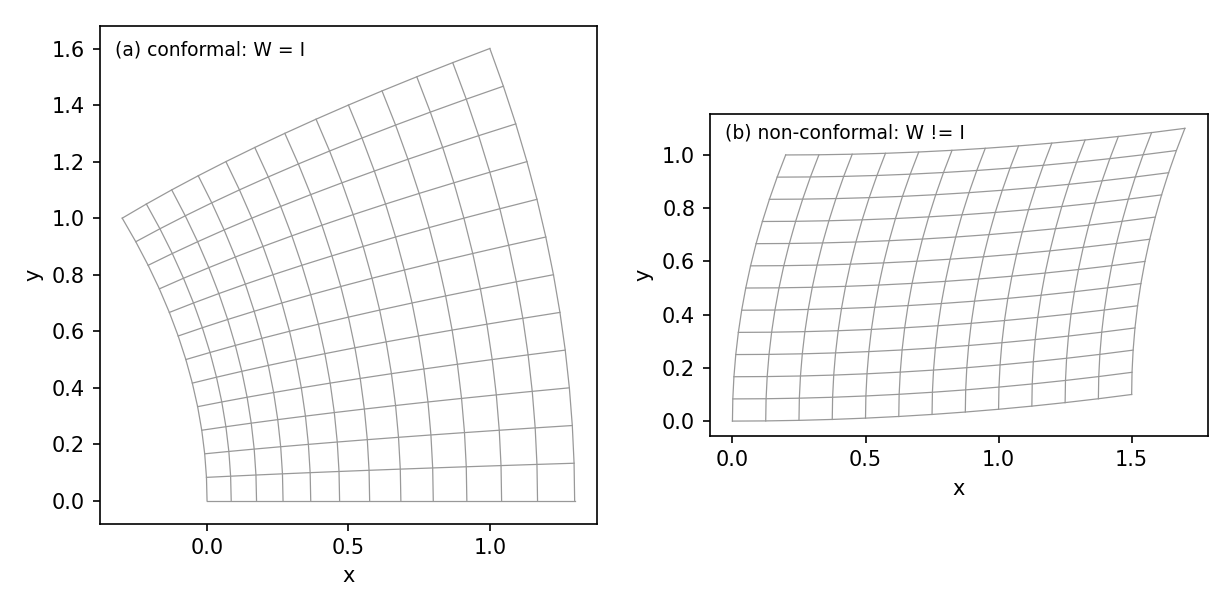

### `hodograph_kelvin_2d.py`  
`docs/clebsch_hodograph/demos/hodograph_kelvin_2d.png`  
sha256 `5448fe616e29171f`

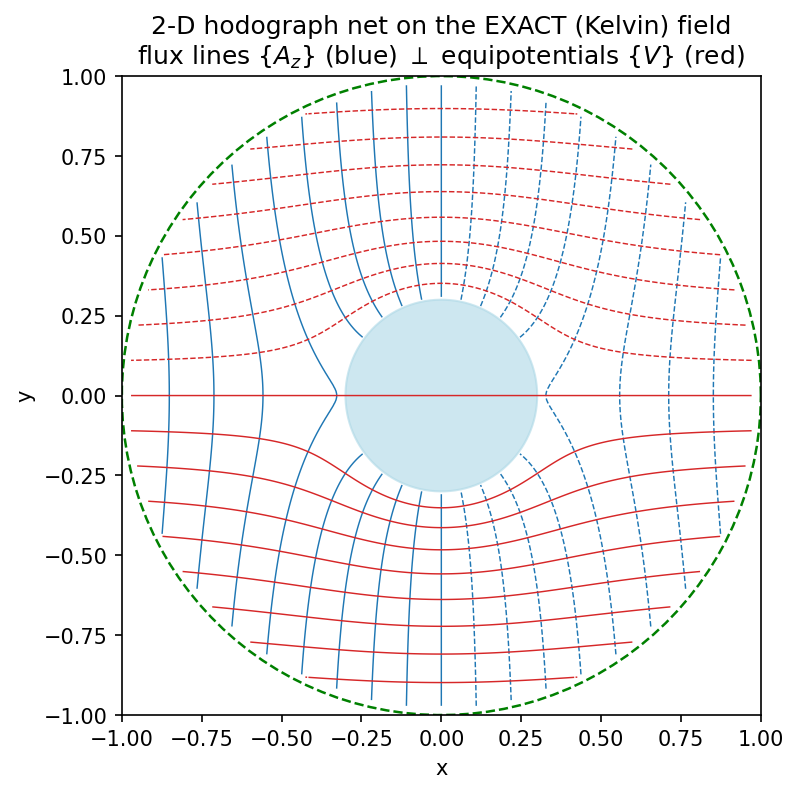

### `hodograph_kelvin_axisym.py`  
`docs/clebsch_hodograph/demos/hodograph_kelvin_axisym.png`  
sha256 `b44cdf00bb5e0282`

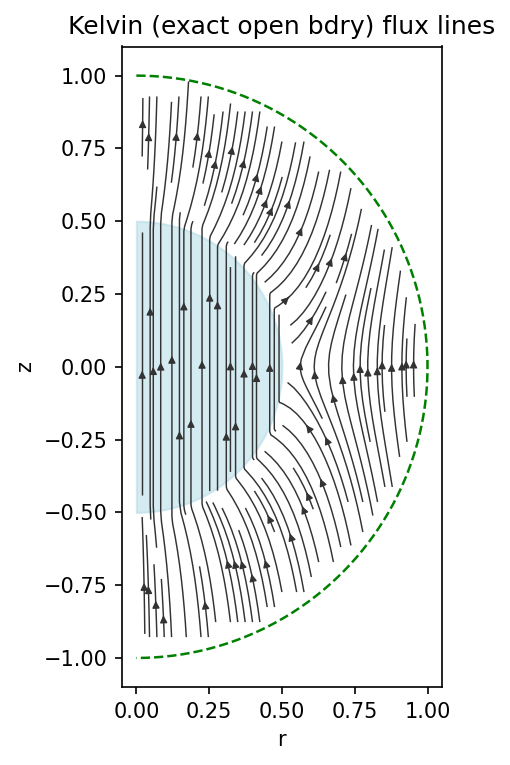

### `clebsch_kelvin_3d.py`  
`docs/clebsch_hodograph/demos/clebsch_kelvin_3d.png`  
sha256 `c3ef4324eb0faf53`

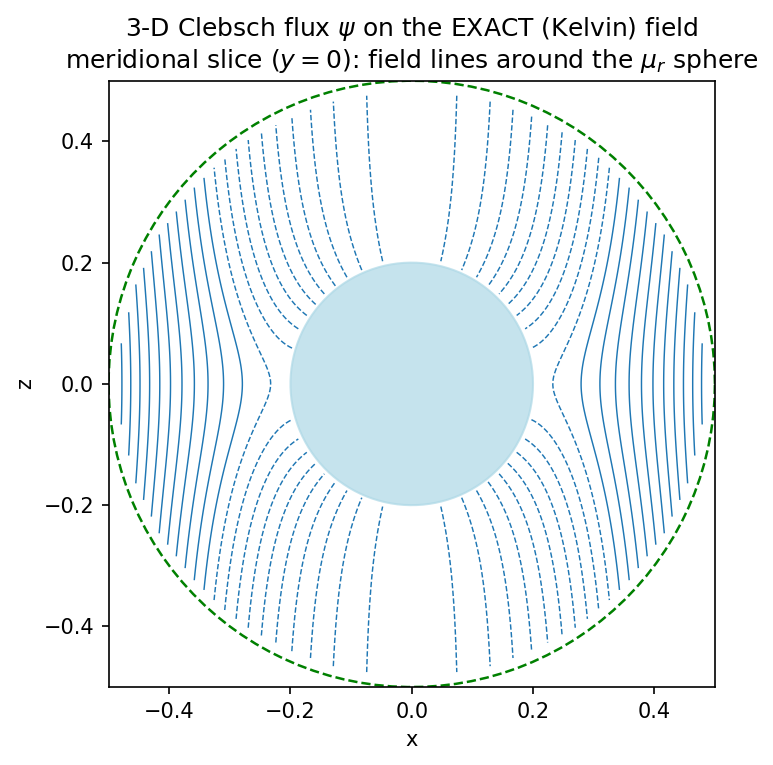

### `chaplygin_hodograph_2d.py`  
`docs/clebsch_hodograph/demos/chaplygin_hodograph_2d.png`  
sha256 `9de1b3fc48880535`

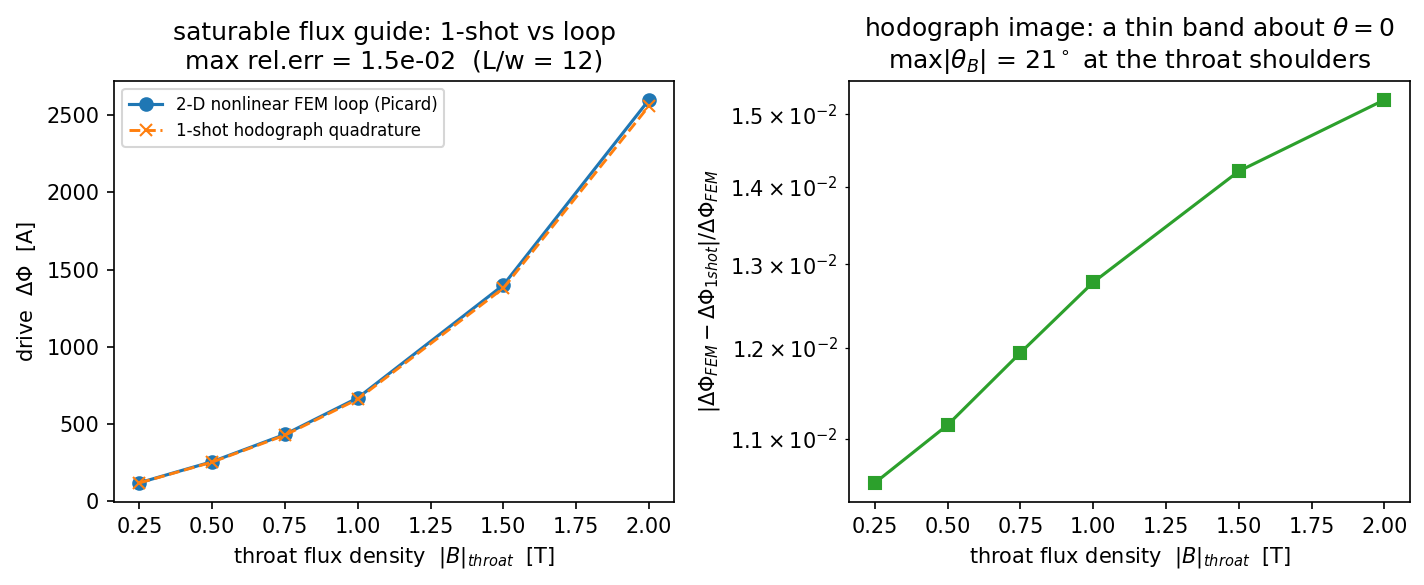

### `a_method_clebsch_2d.py`  
`docs/clebsch_hodograph/demos/a_method_clebsch_2d.png`  
sha256 `e69353ad82dadf02`

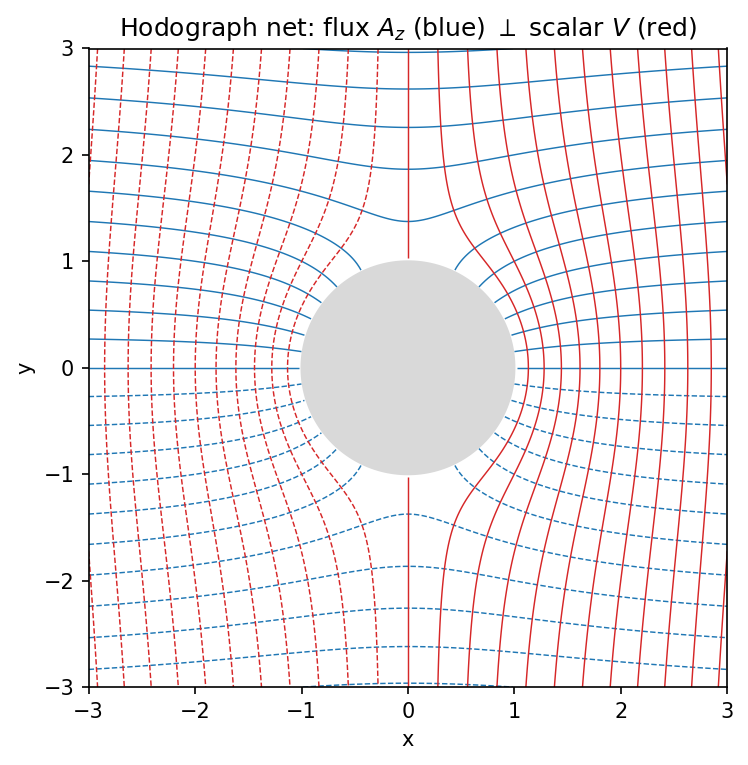

### `accel_pole_design.py`  
`docs/clebsch_hodograph/demos/accel_pole_design.png`  
sha256 `eee9e94c69bbe6ea`

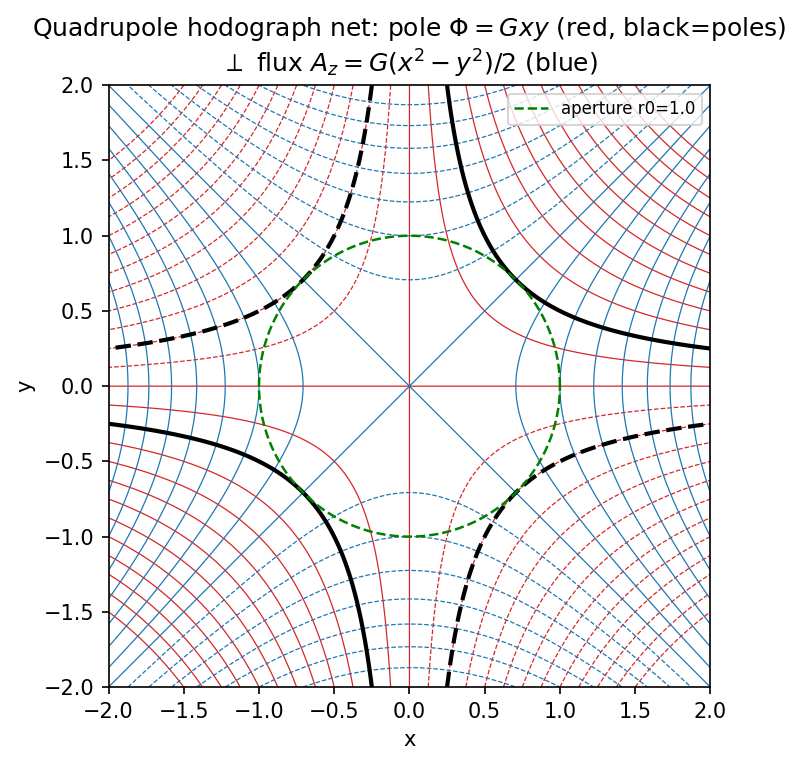

### `endpack_cobake_loft.py`  
`docs/clebsch_hodograph/demos/endpack_cobake_loft.png`  
sha256 `7a80fdd8a7010f92`

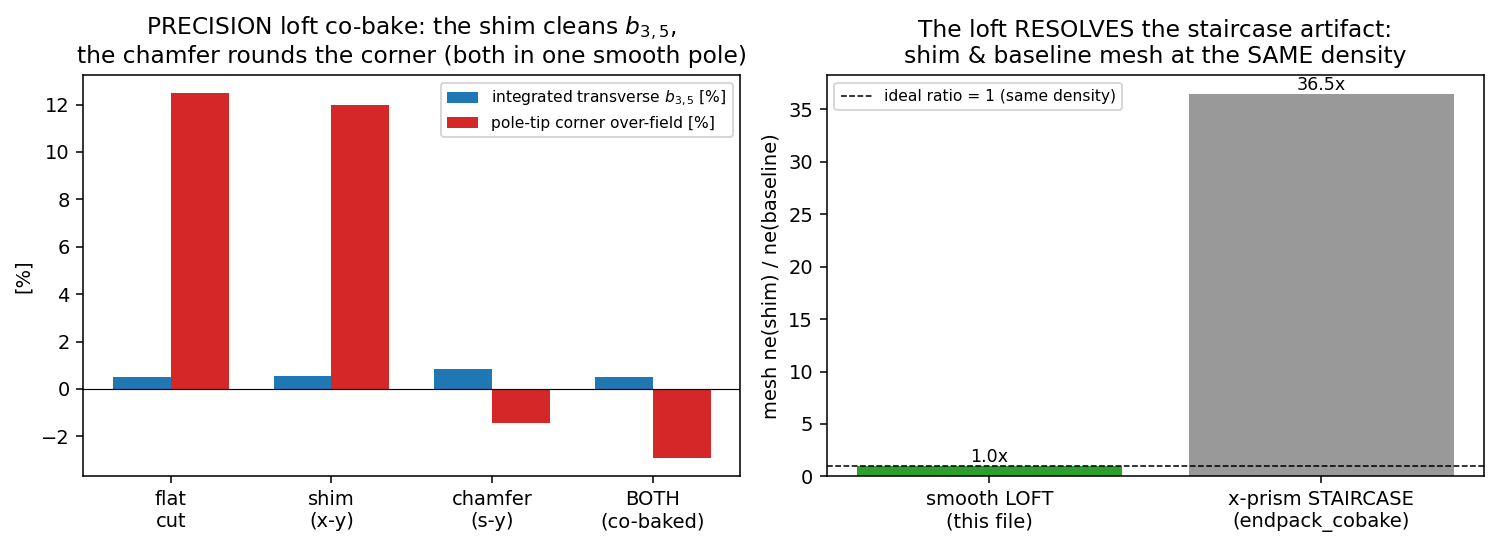

In [4]:
display(Markdown('## Saved figures from the runnable companions'))
for item in demo['selected_images']:
    path = REPO / item['path']
    display(Markdown(f'### `{item["script"]}`  \n`{item["path"]}`  \nsha256 `{item["sha256"][:16]}`'))
    display(Image(filename=str(path), width=560))

In [5]:
protected = [r for r in catalog['records'] if r['protected_reference_count']]
rows = []
for r in protected[:12]:
    first = r['protected_references'][0] if r['protected_references'] else {}
    where = f'{first.get("path", "")}:{first.get("line", "")}' if first else '-'
    rows.append([f'[`{r["name"]}`](../../{r["path"]})', r['protected_reference_count'], where])
md = '## Protected validation references\n\n' + '\n'.join(['| script | refs | first protected reference |', '| --- | ---: | --- |'] + [f'| {a} | {b} | {c} |' for a,b,c in rows])
display(Markdown(md))

## Protected validation references

| script | refs | first protected reference |
| --- | ---: | --- |
| [`a_method_clebsch_2d.py`](../../docs/clebsch_hodograph/demos/a_method_clebsch_2d.py) | 2 | docs/clebsch_hodograph/DESIGN_METHODOLOGY.md:785 |
| [`accel_pole_design.py`](../../docs/clebsch_hodograph/demos/accel_pole_design.py) | 2 | docs/clebsch_hodograph/DESIGN_METHODOLOGY.md:788 |
| [`accel_pole_dipole_body_2d.py`](../../docs/clebsch_hodograph/demos/accel_pole_dipole_body_2d.py) | 1 | src/radia.egg-info/SOURCES.txt:161 |
| [`accel_pole_ends_3d.py`](../../docs/clebsch_hodograph/demos/accel_pole_ends_3d.py) | 2 | docs/clebsch_hodograph/DESIGN_METHODOLOGY.md:789 |
| [`accel_pole_ends_fem.py`](../../docs/clebsch_hodograph/demos/accel_pole_ends_fem.py) | 2 | docs/clebsch_hodograph/DESIGN_METHODOLOGY.md:790 |
| [`accel_pole_harmonics.py`](../../docs/clebsch_hodograph/demos/accel_pole_harmonics.py) | 1 | src/radia.egg-info/SOURCES.txt:164 |
| [`accel_quad_ends_fem.py`](../../docs/clebsch_hodograph/demos/accel_quad_ends_fem.py) | 1 | src/radia.egg-info/SOURCES.txt:165 |
| [`bidirectional_coordinate_transform_2d.py`](../../docs/clebsch_hodograph/demos/bidirectional_coordinate_transform_2d.py) | 3 | docs/clebsch_hodograph/HODOGRAPH_BACKBONE.md:56 |
| [`chaplygin_design_sweep_2d.py`](../../docs/clebsch_hodograph/demos/chaplygin_design_sweep_2d.py) | 1 | src/radia.egg-info/SOURCES.txt:167 |
| [`chaplygin_free_boundary_2d.py`](../../docs/clebsch_hodograph/demos/chaplygin_free_boundary_2d.py) | 1 | src/radia.egg-info/SOURCES.txt:168 |
| [`chaplygin_hodograph_2d.py`](../../docs/clebsch_hodograph/demos/chaplygin_hodograph_2d.py) | 1 | src/radia.egg-info/SOURCES.txt:169 |
| [`chaplygin_inverse_nonlinear_2d.py`](../../docs/clebsch_hodograph/demos/chaplygin_inverse_nonlinear_2d.py) | 1 | src/radia.egg-info/SOURCES.txt:170 |

In [6]:
for name in ['hodograph_kelvin_2d.py', 'chaplygin_hodograph_2d.py', 'accel_pole_design.py']:
    r = next(x for x in demo['selected_records'] if x['name'] == name)
    excerpt = r['source']['text'][:1100].replace('```', '` ` `')
    display(Markdown(f'## Source excerpt: `{r["path"]}`\n\n```python\n{excerpt}\n```'))

## Source excerpt: `docs/clebsch_hodograph/demos/hodograph_kelvin_2d.py`

```python
"""Hodograph + Kelvin in 2-D Cartesian: an EXACT open boundary, no air box.

RESEARCH example (track A, rung 1 of "Kelvin in the hodograph").  The dipole
FEM rung truncates the exterior with a Dirichlet AIR BOX; this replaces it with
the **2-D Cartesian Kelvin transformation**, which is especially clean:

  In 2-D the Dirichlet energy INT |grad u|^2 is CONFORMALLY INVARIANT, and the
  Kelvin inversion z -> R^2 / z-bar is conformal -- so the Kelvin exterior is
  WEIGHT-FREE (mu' = mu0, no (R/rho')^2 factor, unlike the axisymmetric case in
  hodograph_kelvin_axisym.py).  The open boundary at infinity maps to a single
  interior point (GND), and the field is exact.

This is the classical complex-potential pole-design picture made into an FEM
realisation with an exact open boundary.  In a current-free 2-D region the flux
function A_z and the scalar potential V are CAUCHY-RIEMANN CONJUGATES:
``W = A_z + i mu0 V`` is analytic, so the orthogonal nets {A_z = const} (flux
lines) and {V = const} (equipotentials) ARE the hodograph grid.  The Kelvin
inversion is conformal, so W extends analytica
```

## Source excerpt: `docs/clebsch_hodograph/demos/chaplygin_hodograph_2d.py`

```python
"""Chaplygin rung 1.5b: the 2-D hodograph LINEARISES saturation -- a 1-shot
quadrature that reproduces the full nonlinear FEM loop, on a special geometry
whose hodograph image is a simple region.

RESEARCH example (track A, "Kelvin in the hodograph", the Chaplygin rung).  The
companion ``saturation_loop_2d.py`` shows the straightforward NONLINEAR LOOP (a
saturable cylinder, solved by Picard).  THIS file shows the other half the user
asked for ("hodograph 変換をすると どーせ反復が必要なので 非線形ループと混ぜて
短くできないか?"): the **hodograph turns the nonlinear magnetostatic PDE into a
LINEAR one**, so for a special geometry it is solved in ONE shot (no iteration),
and that 1-shot agrees with the nonlinear loop.


THE MAGNETOSTATICS <-> COMPRESSIBLE-FLOW DICTIONARY
---------------------------------------------------
2-D current-free nonlinear magnetostatics is *identical* to 2-D steady
irrotational compressible gas flow:

    magnetics                          compressible flow
    ------------------------------     -----------------------------------
    H = grad(Phi)   (curl H = 0)       v = grad(phi)   (irrotat
```

## Source excerpt: `docs/clebsch_hodograph/demos/accel_pole_design.py`

```python
"""Accelerator pole design via the hodograph -- design + measurement foundation.

RESEARCH example.  First rung of the "hodograph inverse design + HDiv-VIM
nonlinear forward" combination (the radia selling point): the pieces every
forward verification needs --

  1. multipoles(B, r_ref) -- the MULTIPLE harmonic analyzer.  Samples the
     field on a reference circle and FFTs it into normal b_n / skew a_n
     multipoles (accelerator convention  By + i Bx = sum_n (b_n + i a_n)
     z^{n-1},  z = x + iy;  n=1 dipole, n=2 quad, n=3 sextupole).  This is
     how "field quality / good-field region" is measured.

  2. the hodograph POLE GEOMETRY.  The iron pole face is an equipotential
     of the magnetic scalar potential Phi (high mu -> H_t = 0 -> Phi=const).
     For a multipole the complex potential is W ~ z^n, so:
        dipole (n=1):  Phi = (B0/mu0) y   -> pole  y = const   (flat)
        quad   (n=2):  Phi = G xy         -> pole  xy = r0^2/2  (hyperbola)
        sext   (n=3):  Phi = Im(z^3)*c    -> pole  Im(z^3)=const
     and the orthogonal flux net A_z = Re(W) (quad: A_z = G(x^2-
```

In [7]:
assert demo['summary']['selected_demo_count'] == len(demo['selected_records'])
assert demo['summary']['selected_image_count'] == len(demo['selected_images'])
assert catalog['summary']['script_count'] == 46
assert catalog['summary']['protected_script_count'] == 46
assert all(r['source']['text'] for r in demo['selected_records'])
print('clebsch_hodograph public notebook layer is synchronized; examples remain protected runnable companions')

clebsch_hodograph public notebook layer is synchronized; examples remain protected runnable companions
